In [3]:
from typing import TypedDict, Literal



In [4]:
from typing import TypedDict

class PortfolioState(TypedDict):

    amount_usd : float
    total_usd : float
    target_currency : Literal['INR' , 'EUR']
    total : float

    

In [7]:
def calc_total(state : PortfolioState) -> PortfolioState:

    state['total_usd'] = state['amount_usd'] * 1.08 
    return state 

def convert_to_inr( state : PortfolioState) -> PortfolioState:

    state['total'] = state['total_usd'] * 96 
    return state 

def convert_to_eur( state : PortfolioState) -> PortfolioState:

    state['total'] = state['total_usd'] * 0.87 
    return state 

def choose_conversion(state : PortfolioState) -> str:

    return state["target_currency"]


In [14]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)

builder.add_node("calc_total_usd" ,calc_total )
builder.add_node("calculate_total_inr_node" , convert_to_inr)
builder.add_node("calculate_total_eur_node", convert_to_eur)


builder.add_edge(START, "calc_total_usd")
builder.add_conditional_edges(
        "calc_total_usd", 
        choose_conversion,
        {
            "INR" : "calculate_total_inr_node",
            "EUR" : "calculate_total_eur_node"
        }
        )

builder.add_edge(["calculate_total_inr_node", "calculate_total_eur_node" ], END)


graph = builder.compile()

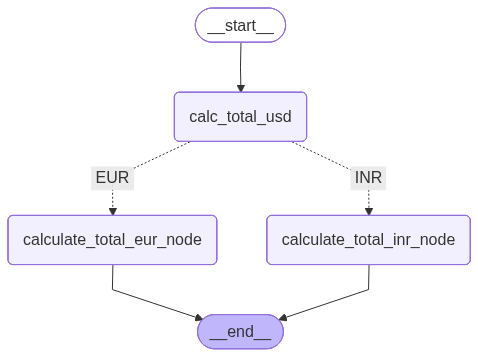

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
graph.invoke({'amount_usd' : 1000 , 'target_currency' : 'EUR'})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_currency': 'EUR',
 'total': 939.6}